In [1]:
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix

import pandas as pd

ds = load_dataset("SetFit/enron_spam")

Repo card metadata block was not found. Setting CardData to empty.


In [2]:
train = pd.DataFrame(ds['train'])
train.head()

,message_id,text,label,label_text,subject,message,date
0,33214,any software just for 15 $ - 99 $ understandin...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,11929,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,19784,wanted to try ci 4 lis but thought it was way ...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,2209,"enron / hpl actuals for december 11 , 2000 tec...",0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,15880,looking for cheap high - quality software ? ro...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 31716 entries, 0 to 31715
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   message_id  31716 non-null  int64         
 1   text        31716 non-null  str           
 2   label       31716 non-null  int64         
 3   label_text  31716 non-null  str           
 4   subject     31716 non-null  str           
 5   message     31716 non-null  str           
 6   date        31716 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(2), str(4)
memory usage: 93.0 MB


## Token Frequency Analysis

In [4]:
import multiprocessing
import spacy

nlp = spacy.load("en_core_web_sm", disable=["parser"])

EMAIL_STOP = {
    "enron", "ect", "hou", "cc", "subject", "re", "fwd", "date", "from", "to", "sent", "received", "message-id", "mime-version", "content-type", "content-transfer-encoding", "x-from", "x-to", "x-cc", "x-bcc", "x-date", "x-message-id", "x-mime-version", "x-content-type", "x-content-transfer-encoding", "let", "know", "would", "could", "get", "also", "thank", "email", "send", "question", "information", "com", "http", "www", "time", "day", "good"
}
STOP = list(EMAIL_STOP) + list(nlp.Defaults.stop_words)

def to_tokens(doc):
    return [t.lemma_.lower() for t in doc
            if t.is_alpha and len(t) > 2 and t.lemma_.lower() not in STOP
            and t.pos_ in {"NOUN", "PROPN", "ADJ", "VERB"}]

texts = train["text"].tolist()
train["tokens"] = [to_tokens(d) for d in nlp.pipe(texts, batch_size = 500, n_process = multiprocessing.cpu_count()-8)]

In [ ]:
train.to_csv("enron_spam_training.csv", index = False)

In [5]:
train_ham = train[train["label_text"] == "ham"]
train_spam = train[train["label_text"] == "spam"]

In [6]:
from collections import Counter
dfreq_ham = Counter((w for toks in train_ham.tokens for w in set(toks)))

print([(w, c) for w, c in dfreq_ham.most_common(100)])

[('need', 4027), ('message', 3816), ('work', 3237), ('regard', 2997), ('new', 2922), ('attach', 2888), ('week', 2680), ('vince', 2670), ('follow', 2652), ('group', 2605), ('gas', 2576), ('deal', 2502), ('look', 2475), ('original', 2472), ('forward', 2470), ('want', 2414), ('schedule', 2395), ('use', 2392), ('corp', 2334), ('change', 2318), ('contact', 2184), ('like', 2143), ('think', 2137), ('file', 2078), ('year', 2064), ('business', 2056), ('houston', 2055), ('energy', 2049), ('number', 2025), ('include', 2021), ('issue', 1997), ('provide', 1981), ('help', 1966), ('meeting', 1954), ('receive', 1949), ('start', 1930), ('mail', 1920), ('kaminski', 1872), ('price', 1870), ('find', 1863), ('market', 1845), ('power', 1800), ('list', 1789), ('today', 1784), ('month', 1752), ('review', 1750), ('discuss', 1733), ('friday', 1730), ('report', 1715), ('management', 1708), ('company', 1703), ('plan', 1693), ('louise', 1681), ('request', 1677), ('system', 1657), ('come', 1652), ('office', 1644), 

In [7]:
from collections import Counter
dfreq_spam = Counter((w for toks in train_spam.tokens for w in set(toks)))

print([(w, c) for w, c in dfreq_spam.most_common(100)])

[('price', 3282), ('need', 3108), ('new', 3049), ('offer', 3015), ('use', 2938), ('money', 2671), ('want', 2630), ('mail', 2566), ('company', 2550), ('receive', 2531), ('click', 2513), ('order', 2509), ('business', 2398), ('look', 2388), ('free', 2362), ('site', 2324), ('message', 2276), ('work', 2075), ('product', 2025), ('year', 2024), ('address', 1986), ('include', 1982), ('net', 1978), ('provide', 1963), ('today', 1926), ('regard', 1902), ('list', 1881), ('future', 1858), ('service', 1858), ('save', 1832), ('find', 1815), ('number', 1813), ('way', 1788), ('stop', 1779), ('low', 1762), ('pay', 1758), ('security', 1746), ('contact', 1734), ('software', 1729), ('result', 1724), ('system', 1717), ('world', 1619), ('wish', 1612), ('online', 1600), ('come', 1598), ('remove', 1595), ('visit', 1585), ('great', 1578), ('life', 1572), ('don', 1571), ('dollar', 1552), ('high', 1551), ('account', 1501), ('available', 1499), ('start', 1497), ('help', 1486), ('month', 1463), ('customer', 1459), 

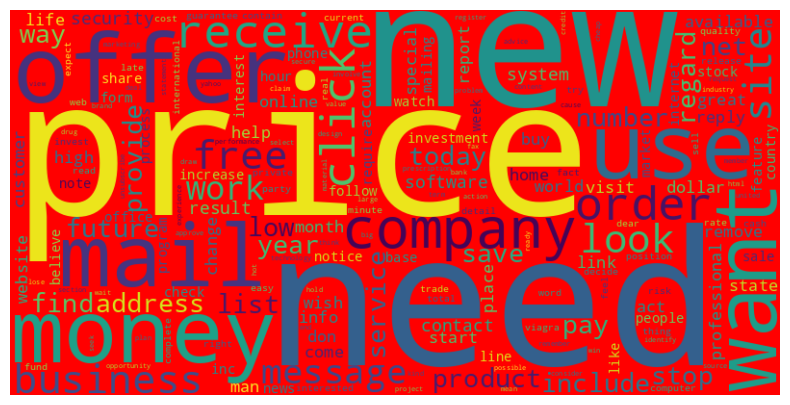

In [8]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Create a word cloud from the SPAM frequency dictionary
wordcloud = WordCloud(width=800, height=400, background_color='red').generate_from_frequencies(dfreq_spam)
wordcloud.to_file("wordcloud_spam.png")
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

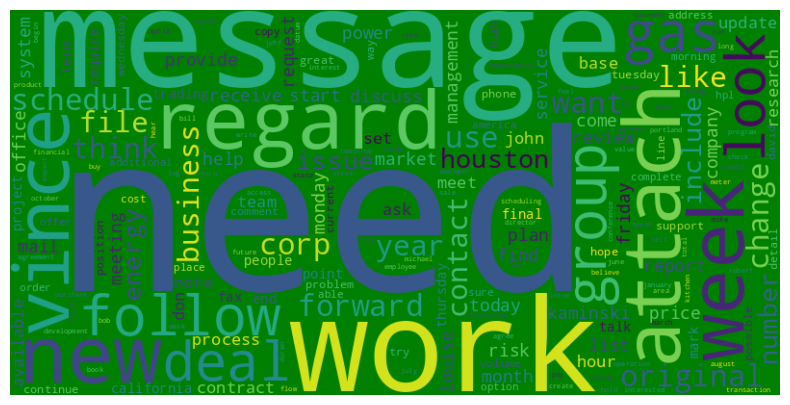

In [9]:
wordcloud = WordCloud(width=800, height=400, background_color='green').generate_from_frequencies(dfreq_ham)
wordcloud.to_file("wordcloud_ham.png")
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

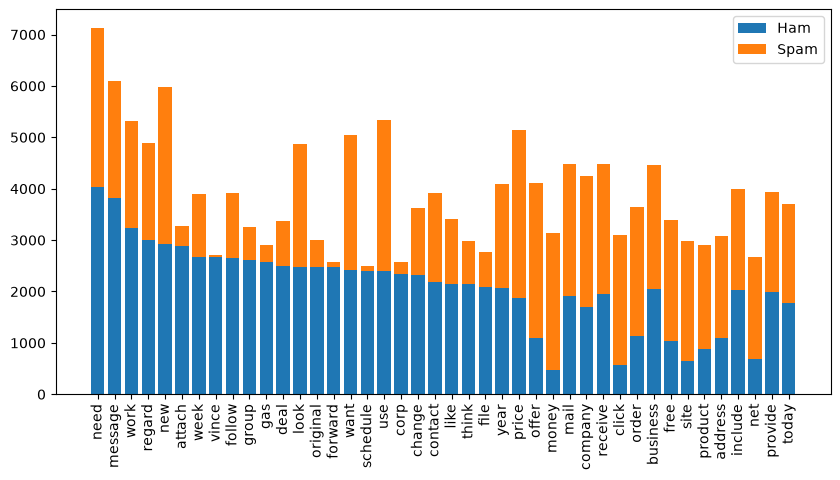

In [13]:
# stacked bar chart of most common ham and spam word counts (stack overlapping tokens)
ham_top = [word for word, _ in dfreq_ham.most_common(25)]
spam_top = [word for word, _ in dfreq_spam.most_common(25)]
tokens = list(dict.fromkeys(ham_top + spam_top))
ham_counts = [dfreq_ham[token] for token in tokens]
spam_counts = [dfreq_spam[token] for token in tokens]

plt.figure(figsize=(10, 5))
plt.bar(tokens, ham_counts, label="Ham")
plt.bar(tokens, spam_counts, bottom=ham_counts, label="Spam")
plt.xticks(rotation=90)
plt.legend()
plt.show()


## Phrases

In [14]:
# individual tokens and wordclouds can only tell us so much. let's see phrases
from gensim.models.phrases import Phrases, ENGLISH_CONNECTOR_WORDS

bigram = Phrases(train.tokens, min_count=20, threshold=100, connector_words=ENGLISH_CONNECTOR_WORDS)

trigram = Phrases(bigram[train.tokens], min_count=20, threshold=100)
train["tokens_ph"] = [trigram[bigram[t]] for t in train.tokens]

In [15]:
# top phrases in spam
print(sorted({w for t in train[train.label_text == "spam"].tokens_ph for w in t if "_" in w})[:50])

['abdominal_fat', 'abidjan_cote', 'abidjan_cote_ivoire', 'ability_encrypt_file', 'abn_amro', 'absolute_confidentiality', 'abuse_program', 'acadia_project', 'acadia_project_acadia_project', 'accept_apology', 'accept_liability', 'accept_liability_error_omission', 'accord_giga_subsidiary_forrester', 'accordance_gaap', 'accumuiated_deficit', 'accumulate_deficit', 'accumulate_deficit_inception', 'accuracy_compieteness', 'accuracy_completeness', 'acheive_resuit', 'acheive_result', 'acheive_result_example_assurance', 'achieve_resuit', 'achieve_resuit_exampie_assurance', 'acknowledge_receipt', 'acre_basin', 'acrobat_professional', 'act_amend', 'act_amend_section_securities', 'act_piease_watch', 'act_section_securities', 'action_active_ingredient', 'action_couid', 'action_couid_occur', 'action_couid_occur_microcap', 'action_identify_use', 'action_occur', 'action_occur_micro_cap', 'action_occur_microcap', 'active_ingredient', 'active_ingredient_tadalafil_brand', 'actua_resuit', 'actua_resuit_eve

Haha they were getting fat loss pills or something

In [16]:
# top phrases in spam
print(sorted({w for t in train[train.label_text == "ham"].tokens_ph for w in t if "_" in w})[:50])

['abn_amro', 'accept_apology', 'accordance_gaap', 'accuracy_completeness', 'acknowledge_receipt', 'act_amend', 'act_amend_section_securities', 'action_occur', 'activity_allocation_exception', 'addressee_indicate', 'adequate_liquidity', 'administration_delete_copy', 'administrative_assistant', 'administrative_coordinator', 'adobe_acrobat', 'adobe_pagemaker', 'advise_employer_consent', 'advisory_board', 'aepin_aepin', 'affiliate_intend_recipient', 'afl_cio', 'afx_news', 'afx_news_afp_extel', 'afxpress_copyright_dow_jones', 'agree_eileen', 'agree_eileen_ponton_david', 'ahmad_lon', 'aig_highstar', 'aimee_lannou', 'aimee_lannou_daren_farmer', 'alan_comnes', 'alberta_canada', 'alex_huang', 'alia_dbcap_datum', 'alia_dbcap_datum_unknown', 'allen_center', 'allen_phillip', 'allocation_exception', 'alp_presentation', 'alport_kysa', 'amelia_alland', 'amendment_ppa', 'american_express', 'ami_chokshi', 'amita_gosalia', 'amitava_dhar', 'amsterdam_netherlands', 'amy_fitzpatrick', 'anatol_feygin', 'anc

## NER Analysis

In [17]:
# spam ner analysis
nlp_ner = spacy.load("en_core_web_sm")
spam_ents = []
for doc in nlp_ner.pipe(train[train.label_text == "spam"]["text"], n_process = multiprocessing.cpu_count()-8):
    spam_ents += [(e.text.strip(), e.label_) for e in doc.ents if e.label_ in ["PERSON", "ORG", "GPE", "MONEY"]]

ent_spam_df = pd.DataFrame(spam_ents, columns=["entity", "label"])
print(ent_spam_df.groupby("label")["entity"].value_counts().groupby(level=0).head(10))

label   entity                     
GPE     china                           759
        canada                          460
        uk                              460
        nbsp                            421
        south africa                    337
        america                         272
        netherlands                     264
        the united states               259
        california                      243
        us                              235
MONEY   1                              1617
        2                               740
        0                               575
        5                               543
        3                               528
        90                              453
        80                              440
        50                              426
        75                              316
        4                               292
ORG     microsoft                       670
        sec                             

In [18]:
# ham ner analysis
ham_ents = []
for doc in nlp_ner.pipe(train[train.label_text == "ham"]["text"], n_process = multiprocessing.cpu_count()-8):
    ham_ents += [(e.text.strip(), e.label_) for e in doc.ents if e.label_ in ["PERSON", "ORG", "GPE", "MONEY"]]

ent_ham_df = pd.DataFrame(ham_ents, columns=["entity", "label"])
print(ent_ham_df.groupby("label")["entity"].value_counts().groupby(level=0).head(10))

label   entity                     
GPE     houston                        4170
        california                     2191
        london                         1689
        new york                       1633
        texas                          1272
        india                           691
        prc                             661
        el paso                         492
        washington                      451
        canada                          430
MONEY   1                              1829
        2                               693
        3                               625
        0                               524
        4                               359
        5                               307
        10                              286
        $ 1 billion                     260
        9                               228
        15                              192
ORG                                   1932
        enron                          1

# Classification Modeling

## TF-IDF

In [73]:
tr, te = ds["train"].to_pandas(), ds["test"].to_pandas()
print(tr.label_text.value_counts())

label_text
spam    16163
ham     15553
Name: count, dtype: int64


In [79]:
# PII masking on text reusing email_cls_with_clustering.pii
from tqdm.auto import tqdm

from email_cls_with_clustering.pii import redact

tqdm.pandas()

def redact_df(df, cols=("embed_text",), lang="en", inplace=False):
    out = df if inplace else df.copy()
    for col in cols:
        out[col] = out[col].fillna("").astype(str).progress_apply(
            lambda t: redact(t, lang=lang)
        )
    return out


# or two frames (e.g. train / test)
tr = redact_df(tr, cols=["text"])
te = redact_df(te, cols=["text"])

  0%|          | 0/31716 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

In [80]:
tr.head()

,message_id,text,label,label_text,subject,message,date
0,33214,any software just for 15 $ - 99 $ understandin...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,11929,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,19784,wanted to try ci 4 lis but thought it was way ...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,2209,"enron / hpl actuals for december 11 , 2000 tec...",0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,15880,looking for cheap high - quality software ? ro...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13


In [81]:
tr.info()

<class 'pandas.DataFrame'>
RangeIndex: 31716 entries, 0 to 31715
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype        
---  ------      --------------  -----        
 0   message_id  31716 non-null  int64        
 1   text        31716 non-null  str          
 2   label       31716 non-null  int64        
 3   label_text  31716 non-null  str          
 4   subject     31716 non-null  str          
 5   message     31716 non-null  str          
 6   date        31716 non-null  datetime64[s]
dtypes: datetime64[s](1), int64(2), str(4)
memory usage: 92.5 MB


In [82]:
from sklearn.feature_extraction.text import TfidfVectorizer


clf = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df = 3, sublinear_tf = True, max_features = 200_000), LogisticRegression(C=4, max_iter = 2000, class_weight = "balanced"))
clf.fit(tr.text, tr.label_text)
pred = clf.predict(te.text)
print(classification_report(te.label_text, pred, target_names=["ham", "spam"]))
print(confusion_matrix(te.label_text, pred, labels=["ham", "spam"]))

              precision    recall  f1-score   support

         ham       0.99      0.98      0.99       992
        spam       0.98      0.99      0.99      1008

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000

[[974  18]
 [  9 999]]


In [83]:
import joblib
joblib.dump(clf, "clf_pii.joblib")

['clf_pii.joblib']

Amazing! Beautiful!

In [25]:
svm = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df = 3, sublinear_tf = True), LinearSVC(C = 0.5))
svm.fit(tr.text, tr.label)
print("LinearSVC accuracy: ", (svm.predict(te.text) == te.label).mean())

LinearSVC accuracy:  0.9885


## Interpretability

In [28]:
vec, lr = clf.named_steps["tfidfvectorizer"], clf.named_steps["logisticregression"]
coefs = pd.Series(lr.coef_[0], index=vec.get_feature_names_out()).sort_values()
print("Ham-indicative features (label == 0):", coefs.head(120).index.tolist()); print("Spam-indicative features (label == 1):", coefs.tail(120).index.tolist())

Ham-indicative features (label == 0): ['enron', 'vince', 'thanks', 'the', '2001', 'attached', '2000', 'louise', '713', 'ect', 'gas', 'enron com', 'on', 'doc', 'energy', 'will', 'houston', 'to', 'pm', 'for', 'please', 'meeting', 'deal', '01', 'hou ect', 'kaminski', 'hou', 'daren', 'power', 'cc', 'password', 'questions', 'congratulations', 'hpl', 'ect ect', 'meter', 'monday', 'at', 'for the', 'sally', 'here is', 'call', 'risk', 'me know', 'employees', 'mark', 'california', 'xls', 'trading', 'steve', 'schedule', 'hourahead', 'update', 'dave', 'john', 'research', 'am', 'hope', 'model', 'let me', 'changes', 'attached is', 'pm to', 'mike', 'will be', 'april', 'texas', '02', 'ena', 'corp', 'group', 'see attached', 'resume', 'start date', 'comments', 'conference', 'week', 'schedules', 'am to', 'would', 'hourahead hour', 'fyi', 'file', 'vince kaminski', 'congratulations on', 'revised', 'issues', 'have', 'cc subject', 'access', 'friday', 'date', 'forwarded', 'jeff', 'bob', 'edu', 'subject', 'pre

In [31]:
te["proba"] = clf.predict_proba(te.text)[:, 1]
errors = te[(te.proba>0.5) != (te.label == 1)].assign(conf = lambda d: (d.proba - 0.5).abs())
errors.sort_values("conf", ascending=False)[["label_text", "label", "proba", "subject", "text"]].head(10)

,label_text,label,proba,subject,text
467,ham,0,0.957273,get a $ 25 certificate just for responding to ...,get a $ 25 certificate just for responding to ...
1385,ham,0,0.838389,re : willis phillips,re : willis phillips willis is an manager cand...
1981,ham,0,0.837280,new email,new email yo bro . this is my new email addres...
55,spam,1,0.180075,nymex invitation - learn power trading,nymex invitation - learn power trading power t...
873,spam,1,0.180075,nymex invitation - learn power trading,nymex invitation - learn power trading power t...
437,ham,0,0.748985,happy friday from hr ! ( cookies ),happy friday from hr ! ( cookies ) hr is wishi...
583,spam,1,0.286926,movie project,movie project hi steph\ni have found the talen...
577,ham,0,0.708813,i ' m out,i ' m out bill - i ' m in copenhagen awaiting ...
149,ham,0,0.686751,kathy crane ' s # @ wapa is :,kathy crane ' s # @ wapa is : 970 - 240 - 6206
1466,ham,0,0.685171,can ' t please everyone,can ' t please everyone thought you might enjo...


Very interesting, since they talk so much about trading in the emails some spam related to that was classified as ham. Informal emails were also leaning more towards spam but were actually ham.

# Classification with embeddings

In [ ]:
from sentence_transformers import SentenceTransformer
st = SentenceTransformer("all-MiniLM-L6-v2")
Etr = st.encode(tr.text.str[:2000].tolist(), batch_size = 128, show_progress_bar = True, normalize_embeddings = True)
Ete = st.encode(te.text.str[:2000].tolist(), batch_size = 128, show_progress_bar = True, normalize_embeddings = True)
elr = LogisticRegression(max_iter = 2000, class_weight = "balanced").fit(Etr, tr.label)
print(classification_report(te.label, elr.predict(Ete), digits = 3, target_names=["ham", "spam"]))

ModuleNotFoundError: No module named 'SentenceTransformer'

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/248 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

              precision    recall  f1-score   support

         ham      0.974     0.966     0.970       992
        spam      0.967     0.974     0.970      1008

    accuracy                          0.970      2000
   macro avg      0.970     0.970     0.970      2000
weighted avg      0.970     0.970     0.970      2000



It's actually a bit worse. Lexical tokenization works much better for these purposes. That's why we have to explore both. This is proof that embeddings may sometimes be overkill!

# Few-shot classification with SetFit

In [ ]:
from setfit import SetFitModel, Trainer, TrainingArguments, sample_dataset
train_fs = sample_dataset(ds["train"], label_column = "label", num_samples = 50) # 50 samples per class
model = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
args = TrainingArguments(
    batch_size = 10,
    num_epochs = 5,
    num_iterations = 20
)
trainer = Trainer(
    model = model,
    args = args,
    train_dataset = train_fs,
    eval_dataset = ds["test"].select(range(2000)),
    column_mapping = {"text": "text", "label": "label"}
)
trainer.train()
print(trainer.evaluate())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 4000
  Batch size = 10
  Num epochs = 5


Step,Training Loss
1,0.651619
50,0.291384
100,0.216588
150,0.109039
200,0.014986
250,0.002716
300,0.001625
350,0.001111
400,0.000612
450,0.000560


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

***** Running evaluation *****


{'accuracy': 0.9445}


In [55]:
history = trainer.st_trainer.state.log_history
# log_history mixes train steps with eval/summary rows that lack embedding_loss
loss_history = [st["embedding_loss"] for st in history if "embedding_loss" in st]

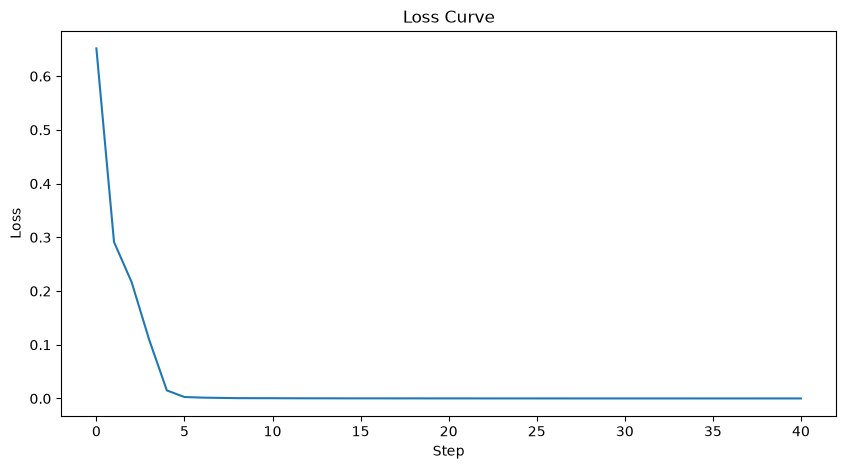

In [56]:
# loss curve
plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.show()

## Zero-shot classificaiton

In [58]:
from transformers import pipeline

zs = pipeline("zero-shot-classification", model = "MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7")
labels = ["billing or payment", "claim status", "complaint", "meeting scheduling", "legal or contract"]
print(zs("Todavía no he recibido el pago de la factura", candidate_labels = labels, hypothesis_template = "This email is about {}", multi_label = False))

config.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

/home/marco/development/email-cls-with-clustering/.venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


model.safetensors: reconstructing file:   0%|          |  0.00B /  558MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 16.3MB            

tokenizer.json: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

{'sequence': 'Todavía no he recibido el pago de la factura', 'labels': ['billing or payment', 'claim status', 'complaint', 'legal or contract', 'meeting scheduling'], 'scores': [0.7658476233482361, 0.10610411316156387, 0.06682923436164856, 0.048258841037750244, 0.012960183434188366]}


## Fine-tuning a small transformer

In [59]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
import evaluate

ckpt = "distilbert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(ckpt)
enc = ds.map(lambda x: tokenizer(x["text"], padding = True, truncation = True), batched = True)
model = AutoModelForSequenceClassification.from_pretrained(ckpt, num_labels = 2)
f1 = evaluate.load("f1")

def metrics(p): return f1.compute(predictions = p.predictions.argmax(axis = 1), references = p.label_ids, average = "macro")

training_args = TrainingArguments(
    output_dir = "ft-enron",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-5,
    per_device_train_batch_size = 32,
    num_train_epochs = 3,
    weight_decay = 0.01,   
)

trainer = Trainer(model = model,
                  args = training_args,
                  train_dataset = enc["train"].shuffle(seed=42).select(range(10000)),
                  eval_dataset = enc["test"],
                  processing_class = tokenizer,
                  compute_metrics = metrics,
                  data_collator = DataCollatorWithPadding(tokenizer = tokenizer))
trainer.train()


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Map:   0%|          | 0/31716 [00:00<?, ? examples/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

## Weak Supervision: Topics -> Labels -> Classifier

In [ ]:
# topic_to_label = {0: "gas_trading", 3: "california_crisis", 7: "scheduling"} # fill after reading topic cards
# weak = df[df.topic.isin(topic_to_label)].assign(y=lambda d: d.topic.map(topic_to_label))
# weak = weak[pd.Series(new_topics, index=df.index).loc[weak.index] == weak.topic]
# wclf = make_pipeline(TfidfVectorizer(min_df=3, ngram_range=(1, 2)),
# LogisticRegression(max_iter=2000, class_weight="balanced"))
# wclf.fit(weak.clean, weak.y)

## Clustering for discovery

In [67]:
from sklearn.cluster import KMeans, HDBSCAN as SkHDBSCAN
from umap import UMAP
km = KMeans(n_clusters=30, n_init="auto", random_state=42).fit(Etr)
umap_emb = UMAP(n_components=10, random_state=42).fit_transform(Etr)
sk_hdb = SkHDBSCAN(min_cluster_size=40, min_samples=11).fit(umap_emb)
print(pd.Series(sk_hdb.labels_).value_counts().head())

/home/marco/development/email-cls-with-clustering/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/marco/development/email-cls-with-clustering/.venv/lib/python3.13/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


-1      12332
 73       776
 85       714
 18       712
 154      648
Name: count, dtype: int64


In [62]:
tr_emb_with_clusters = pd.DataFrame({"text": tr.text, "label_text": tr.label_text, "cluster": km.labels_})

In [63]:
tr_emb_with_clusters.head()

,text,label_text,cluster
0,any software just for 15 $ - 99 $ understandin...,spam,8
1,perspective on ferc regulatory action client c...,ham,0
2,wanted to try ci 4 lis but thought it was way ...,spam,17
3,"enron / hpl actuals for december 11 , 2000 tec...",ham,9
4,looking for cheap high - quality software ? ro...,spam,8


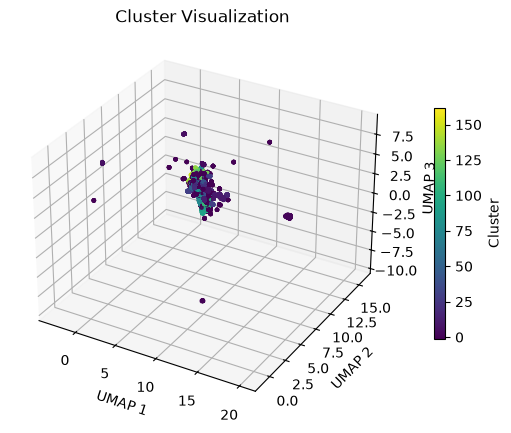

In [72]:
# plot clusters (first 3 UMAP dims used for HDBSCAN)

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(projection="3d")
sc = ax.scatter(
    umap_emb[:, 0], umap_emb[:, 1], umap_emb[:, 2],
    c=sk_hdb.labels_, cmap="viridis", s=5,
)
fig.colorbar(sc, ax=ax, label="Cluster", shrink=0.6)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_zlabel("UMAP 3")
ax.set_title("Cluster Visualization")
plt.show()

Not very disparate it seems